In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

In [2]:
df = pd.read_csv('mymoviedb.csv',lineterminator='\n')

In [3]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   object 
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 691.1+ KB


In [5]:
summary_rows = []

n_rows = len(df)

for column_name, column_data in df.items():

    missing_count = column_data.isna().sum()
    missing_ratio = (missing_count / n_rows) * 100

    example_values = column_data.dropna().unique()[:3]
    example_preview = ", ".join(map(str, example_values))[:60]

    summary_rows.append({
        "column_name": column_name,
        "dtype": column_data.dtype,
        "unique_values": column_data.nunique(),
        "missing_count": missing_count,
        "missing_percent": round(missing_ratio, 2),
        "example_values": example_preview
    })

dataset_summary = pd.DataFrame(summary_rows)

display(
    dataset_summary.style.set_properties(**{"text-align": "left"})
)

,column_name,dtype,unique_values,missing_count,missing_percent,example_values
0,Release_Date,object,5893,0,0.000000,"2021-12-15, 2022-03-01, 2022-02-25"
1,Title,object,9513,0,0.000000,"Spider-Man: No Way Home, The Batman, No Exit"
2,Overview,object,9822,0,0.000000,Peter Parker is unmasked and no longer able to separate his
3,Popularity,float64,8160,0,0.000000,"5083.954, 3827.658, 2618.087"
4,Vote_Count,int64,3266,0,0.000000,"8940, 1151, 122"
5,Vote_Average,float64,74,0,0.000000,"8.3, 8.1, 6.3"
6,Original_Language,object,43,0,0.000000,"en, ja, fr"
7,Genre,object,2337,0,0.000000,"Action, Adventure, Science Fiction, Crime, Mystery, Thriller"
8,Poster_Url,object,9827,0,0.000000,https://image.tmdb.org/t/p/original/1g0dhYtq4irTY1GPXvft6k4Y


In [6]:
df['Genre'].head()

0    Action, Adventure, Science Fiction
1              Crime, Mystery, Thriller
2                              Thriller
3    Animation, Comedy, Family, Fantasy
4      Action, Adventure, Thriller, War
Name: Genre, dtype: object

In [7]:
# Checking duplicate values in the dataframe
df.duplicated().sum()

0

In [8]:
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534
std,108.873998,2611.206907,1.129759
min,13.354000,0.000000,0.000000
25%,16.128500,146.000000,5.900000
50%,21.199000,444.000000,6.500000
75%,35.191500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


### Exploration Summary
- we have a dataframe consisting of 9827 rows and 9 columns.
- our dataset looks a bit tidy with no NaNs nor duplicated values.
- Release_Date column needs to be casted into date time and to extract only the 
- Overview, Original_Languege and Poster-Url wouldn't be so useful during analys
- there is noticable outliers in Popularity column
- Vote_Average bettter be categorised for proper analysis.
- Genre column has comma saperated values and white spaces that needs to be handled and casted into category.

In [10]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'])

In [11]:
print(df['Release_Date'].dtype)

datetime64[ns]


In [12]:
df['Release_Date'] = df['Release_Date'].dt.year
print(df['Release_Date'].dtype)

int32


In [13]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [14]:
df.drop(columns=['Overview','Original_Language','Poster_Url'], axis = 1 , inplace = True)

In [15]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,Thriller
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"


### Numerical columns analysis

In [17]:
num_cols = df.select_dtypes('number').columns.to_list()
def numerical_dist_plot(data: pd.DataFrame):
    '''small functions to plot distribution plot for numerical cols'''
    
    df = data
    
    fig, axes = plt.subplots(1, 4, figsize=(14, 6))
    axes = axes.flatten()
    
    for i, col in enumerate(num_cols[0:5]):   # limit to 4 plots
        sns.histplot(
            df[col],
            kde=True,
            ax=axes[i],
            color="#4C72B0",
            edgecolor="white"
        )
        
        axes[i].set_title(f"Distribution of {col}")
    
    plt.tight_layout()
    sns.despine()
    plt.show()

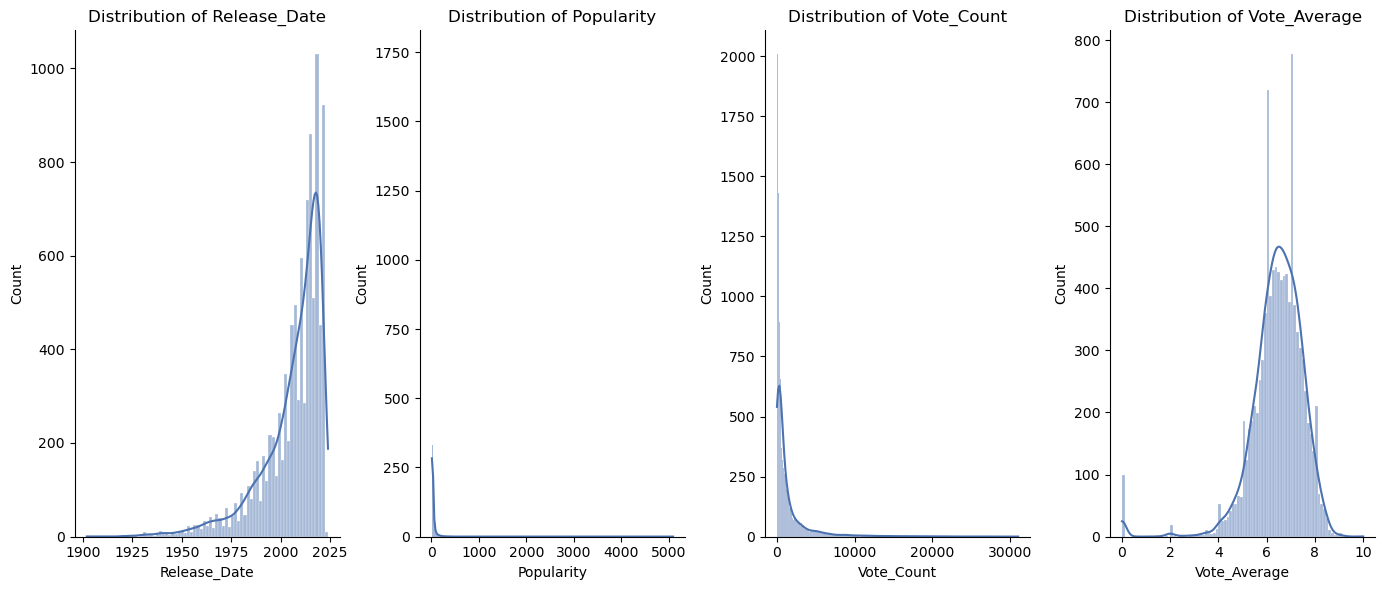

In [18]:
numerical_dist_plot(df)

### categorizing Vote_Average column

In [20]:
def catigorize_col (df, col, labels):
    """
    catigorizes a certain column based on its quartiles
   
    Args:
        (df)     df   - dataframe we are proccesing
        (col)    str  - to be catigorized column's name 
        (labels) list - list of labels from min to max
    
    Returns:
        (df)     df   - dataframe with the categorized col
    """
    
    # setting the edges to cut the column accordingly
    edges = [df[col].describe()['min'],
             df[col].describe()['25%'],
             df[col].describe()['50%'],
             df[col].describe()['75%'],
             df[col].describe()['max']]
    
    df[col] = pd.cut(df[col], edges, labels = labels, duplicates='drop')
    return df

In [21]:
# define labels for edges
labels = ['not_popular', 'below_avg', 'average', 'popular']
# categorize column based on labels and edges
catigorize_col(df, 'Vote_Average', labels)
# confirming changes
df['Vote_Average'].unique()

['popular', 'below_avg', 'average', 'not_popular', NaN]
Categories (4, object): ['not_popular' < 'below_avg' < 'average' < 'popular']

In [22]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_avg,Thriller
3,2021,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"


In [23]:
df['Vote_Average'].value_counts()

Vote_Average
not_popular    2467
popular        2450
average        2412
below_avg      2398
Name: count, dtype: int64

In [24]:
df.isna().sum()

Release_Date      0
Title             0
Popularity        0
Vote_Count        0
Vote_Average    100
Genre             0
dtype: int64

In [25]:
df.dropna(inplace = True)

In [26]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_avg,Thriller
3,2021,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"


#### we'd split genres into a list and then explode our dataframe to have only one genre per row for each movie

In [28]:
df1 = df.copy()

In [29]:
df1['Genre'] = df1['Genre'].str.split(', ')

df1 = df1.explode('Genre').reset_index(drop = True)

df1.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


In [30]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_avg,Thriller
3,2021,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"


In [31]:
df1['Genre'] = df1['Genre'].astype('category')

In [32]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25552 entries, 0 to 25551
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Date  25552 non-null  int32   
 1   Title         25552 non-null  object  
 2   Popularity    25552 non-null  float64 
 3   Vote_Count    25552 non-null  int64   
 4   Vote_Average  25552 non-null  category
 5   Genre         25552 non-null  category
dtypes: category(2), float64(1), int32(1), int64(1), object(1)
memory usage: 749.6+ KB


In [33]:
df1.nunique()

Release_Date     100
Title           9415
Popularity      8088
Vote_Count      3265
Vote_Average       4
Genre             19
dtype: int64

# Data Visualization

In [35]:
sns.set_style('whitegrid')

In [36]:
# Visualizing genre
df1['Genre'].describe()

count     25552
unique       19
top       Drama
freq       3715
Name: Genre, dtype: object

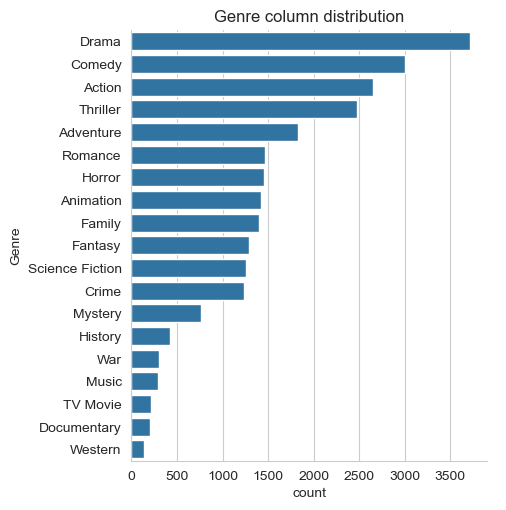

In [37]:
sns.catplot(y = 'Genre' , data = df1 , kind = 'count' , order = df1['Genre'].value_counts().index)
plt.title("Genre column distribution")
plt.show()

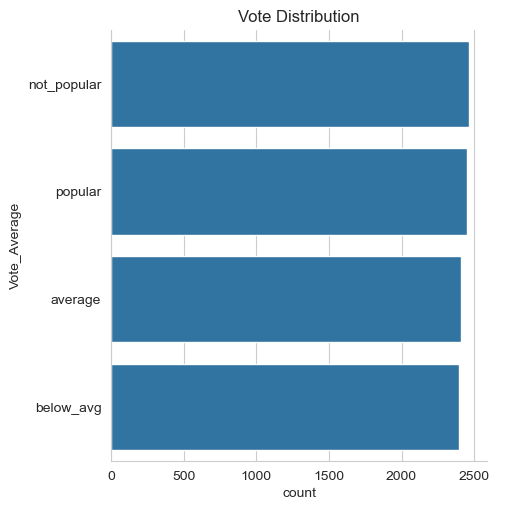

In [38]:
## Which has highest votes in vote avg column ?

sns.catplot(y = 'Vote_Average' , data = df , kind = 'count' , order = df['Vote_Average'].value_counts().index)
plt.title("Vote Distribution")
plt.show()

In [39]:
df['Vote_Average'].describe()

count            9727
unique              4
top       not_popular
freq             2467
Name: Vote_Average, dtype: object

In [40]:
## Which movie has got the highest popularity ? What is its genre ?

df[df['Popularity'] == df['Popularity'].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"


In [41]:
## Which movie has got the lowest popularity ? What is its genre ?

df[df['Popularity'] == df['Popularity'].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
9825,2021,The United States vs. Billie Holiday,13.354,152,average,"Music, Drama, History"
9826,1984,Threads,13.354,186,popular,"War, Drama, Science Fiction"


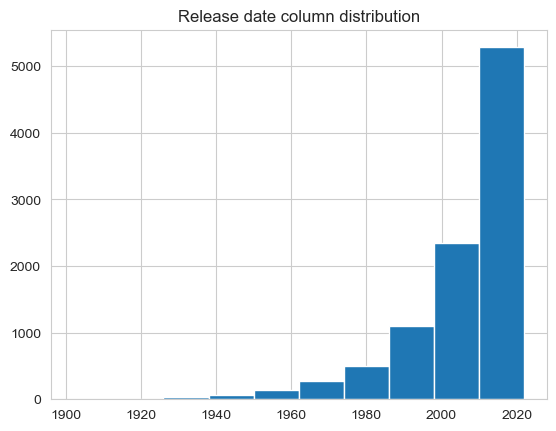

In [42]:
## Which year has the most films?

df['Release_Date'].hist()
plt.title("Release date column distribution")
plt.show()